In [10]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from src.data_loader import load_data

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 

In [11]:
df = load_data()
df['started_at']   = pd.to_datetime(df['started_at'])
df['ended_at']     = pd.to_datetime(df['ended_at'])
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df = df[(df['duration_min'] > 0) & (df['duration_min'] <= 180)].copy()

print(f'총 레코드 수: {len(df):,}')

총 레코드 수: 28,165,708


In [12]:
print(df.columns)

Index(['started_at', 'ended_at', 'start_lat', 'start_lng', 'end_lat',
       'end_lng', 'duration_min'],
      dtype='object')


In [13]:
# 출발 / 도착 스테이션별 이용 수
start_cnt = (
    df.groupby(['start_lat', 'start_lng'])
      .size()
      .reset_index(name='depart_count')
      .sort_values('depart_count', ascending=False)
)
end_cnt = (
    df.groupby(['end_lat', 'end_lng'])
      .size()
      .reset_index(name='arrive_count')
      .sort_values('arrive_count', ascending=False)
)

In [14]:
print(start_cnt.head(10).to_string(index=False))

 start_lat  start_lng  depart_count
 40.741741 -73.994156         97197
 40.717548 -74.013222         95008
 40.746872 -74.008209         93454
 40.730206 -73.991028         87364
 40.752567 -73.996765         80404
 40.766953 -73.981697         80289
 40.749157 -73.991600         80082
 40.760300 -73.998840         79974
 40.734547 -73.990738         79033
 40.734814 -73.992088         78158


In [15]:
print(end_cnt.head(10).to_string(index=False))

  end_lat    end_lng  arrive_count
40.741741 -73.994156         97329
40.717548 -74.013222         95166
40.746872 -74.008209         93589
40.730206 -73.991028         87590
40.752567 -73.996765         80853
40.749157 -73.991600         79761
40.760300 -73.998840         79589
40.766953 -73.981697         78978
40.734814 -73.992088         78292
40.734547 -73.990738         78281


In [18]:
start_cnt['station_pos'] = start_cnt['start_lat'].astype(str) + ", " + start_cnt['start_lng'].astype(str)
end_cnt['station_pos'] = end_cnt['end_lat'].astype(str) + ", " + end_cnt['end_lng'].astype(str)

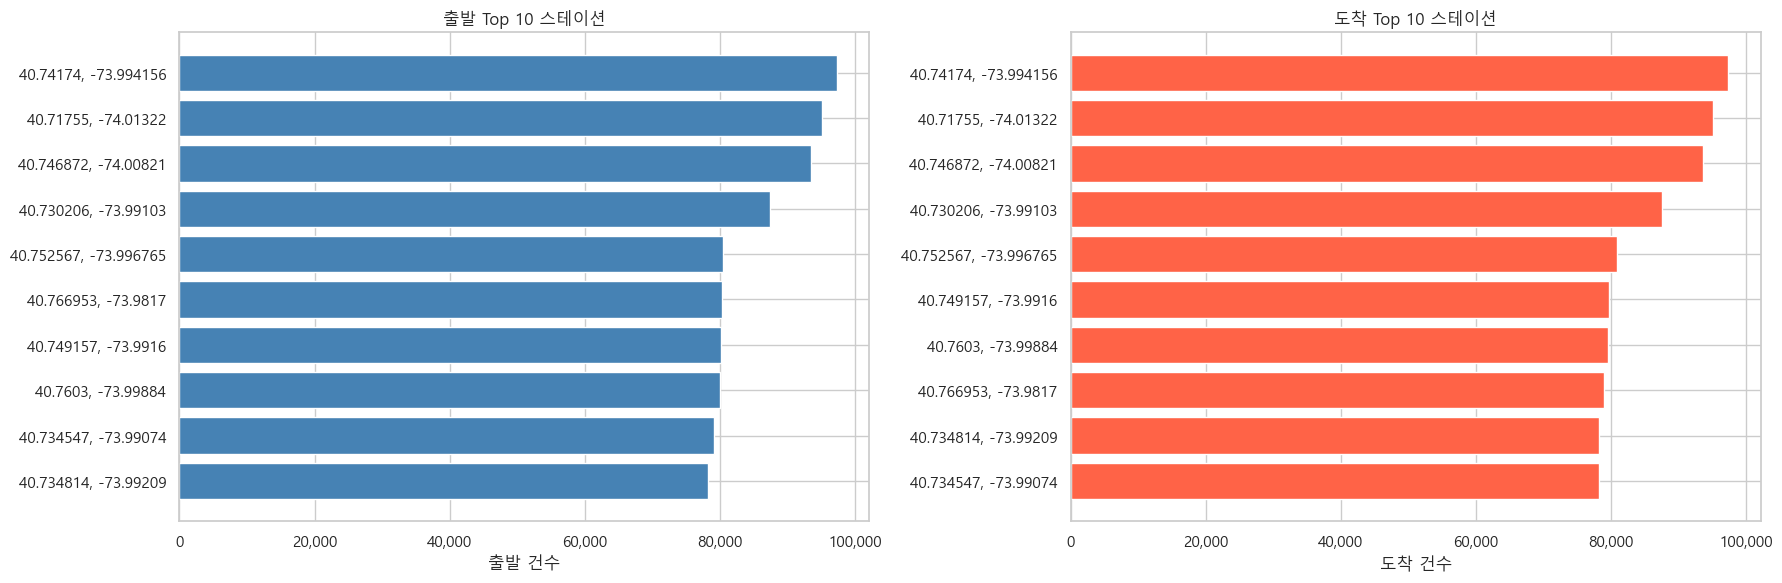

In [19]:
# Top 10 출발 / 도착 스테이션 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(start_cnt.head(10)['station_pos'],
             start_cnt.head(10)['depart_count'],
             color='steelblue', edgecolor='white')
axes[0].set_title('출발 Top 10 스테이션')
axes[0].set_xlabel('출발 건수')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(end_cnt.head(10)['station_pos'],
             end_cnt.head(10)['arrive_count'],
             color='tomato', edgecolor='white')
axes[1].set_title('도착 Top 10 스테이션')
axes[1].set_xlabel('도착 건수')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

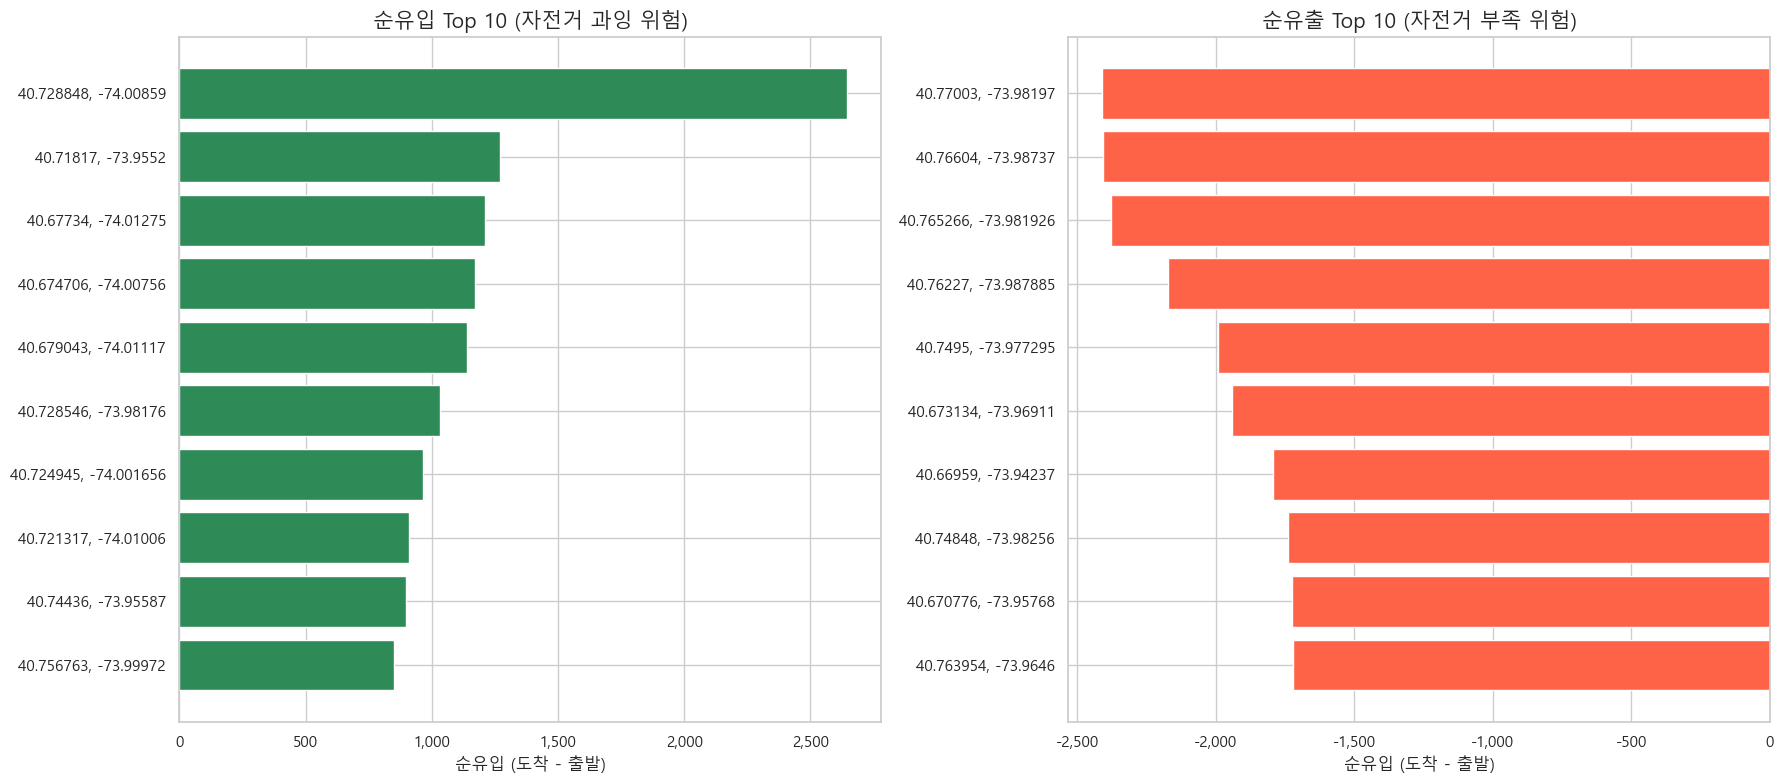

In [ ]:
# 스테이션별 순유입 (도착 - 출발)

# 출발(start)과 도착(end) 데이터를 위도/경도 기준으로
balance = pd.merge(
    start_cnt[['start_lat', 'start_lng', 'depart_count', 'station_pos']], 
    end_cnt[['end_lat', 'end_lng', 'arrive_count', 'station_pos']],
    left_on=['start_lat', 'start_lng'], 
    right_on=['end_lat', 'end_lng'],
    how='outer'
).fillna(0)

# 순유입 계산 (도착 - 출발)
balance['net_inflow'] = balance['arrive_count'] - balance['depart_count']

# 스테이션 이름(좌표 문자열) 정리
# 출발지 기준 좌표가 없으면 도착지 기준 좌표를 사용
balance['station_display_name'] = balance['station_pos_x'].where(balance['station_pos_x'] != 0, balance['station_pos_y'])

# 상위/하위 10개 추출
top_inflow = balance.nlargest(10, 'net_inflow')
top_outflow = balance.nsmallest(10, 'net_inflow')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 순유입 Top 10 
axes[0].barh(top_inflow['station_display_name'], top_inflow['net_inflow'],
             color='seagreen', edgecolor='white')
axes[0].set_title('순유입 Top 10 (자전거 과잉 위험)', fontsize=15) # 도착이 더 많음
axes[0].set_xlabel('순유입 (도착 - 출발)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 순유출 Top 10 
axes[1].barh(top_outflow['station_display_name'], top_outflow['net_inflow'],
             color='tomato', edgecolor='white')
axes[1].set_title('순유출 Top 10 (자전거 부족 위험)', fontsize=15) # 출발이 더 많음
axes[1].set_xlabel('순유입 (도착 - 출발)')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

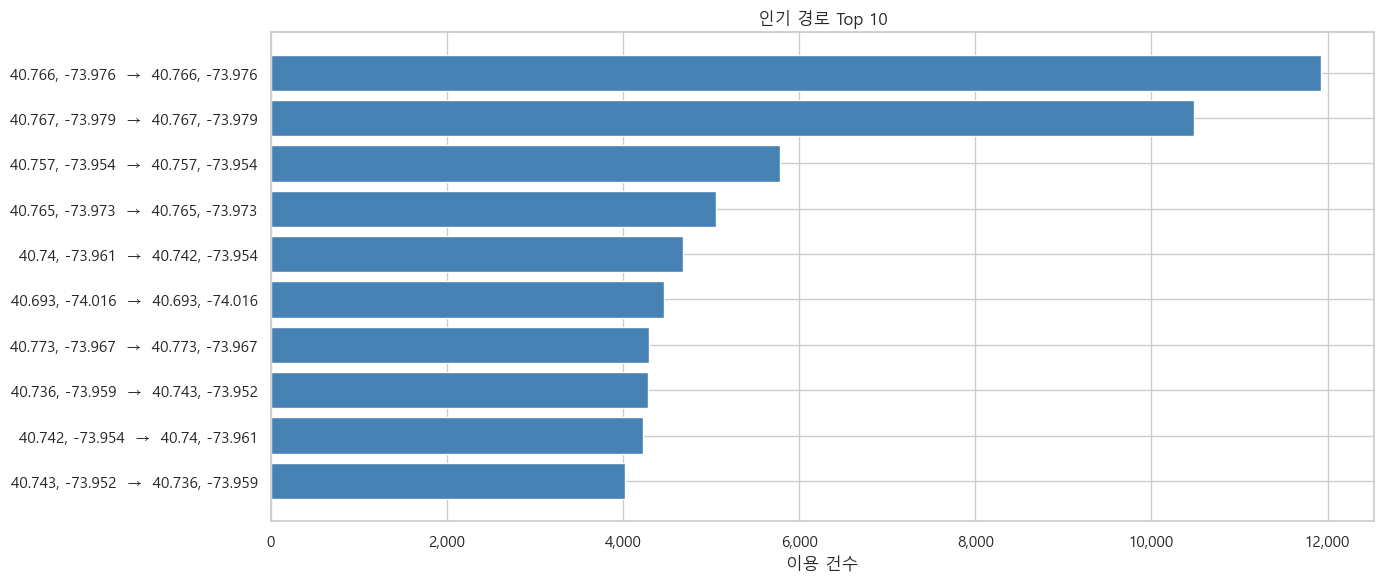

In [24]:
# 인기 출발-도착 경로 Top 10
route_cnt = (
    df.groupby(['start_lat', 'start_lng', 'end_lat', 'end_lng'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)
route_cnt['route'] = (
    route_cnt['start_lat'].round(3).astype(str) + ", " + route_cnt['start_lng'].round(3).astype(str) + 
    '  →  ' + 
    route_cnt['end_lat'].round(3).astype(str) + ", " + route_cnt['end_lng'].round(3).astype(str)
)
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(route_cnt.head(10)['route'], route_cnt.head(10)['count'],
        color='steelblue', edgecolor='white')
ax.set_title('인기 경로 Top 10')
ax.set_xlabel('이용 건수')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

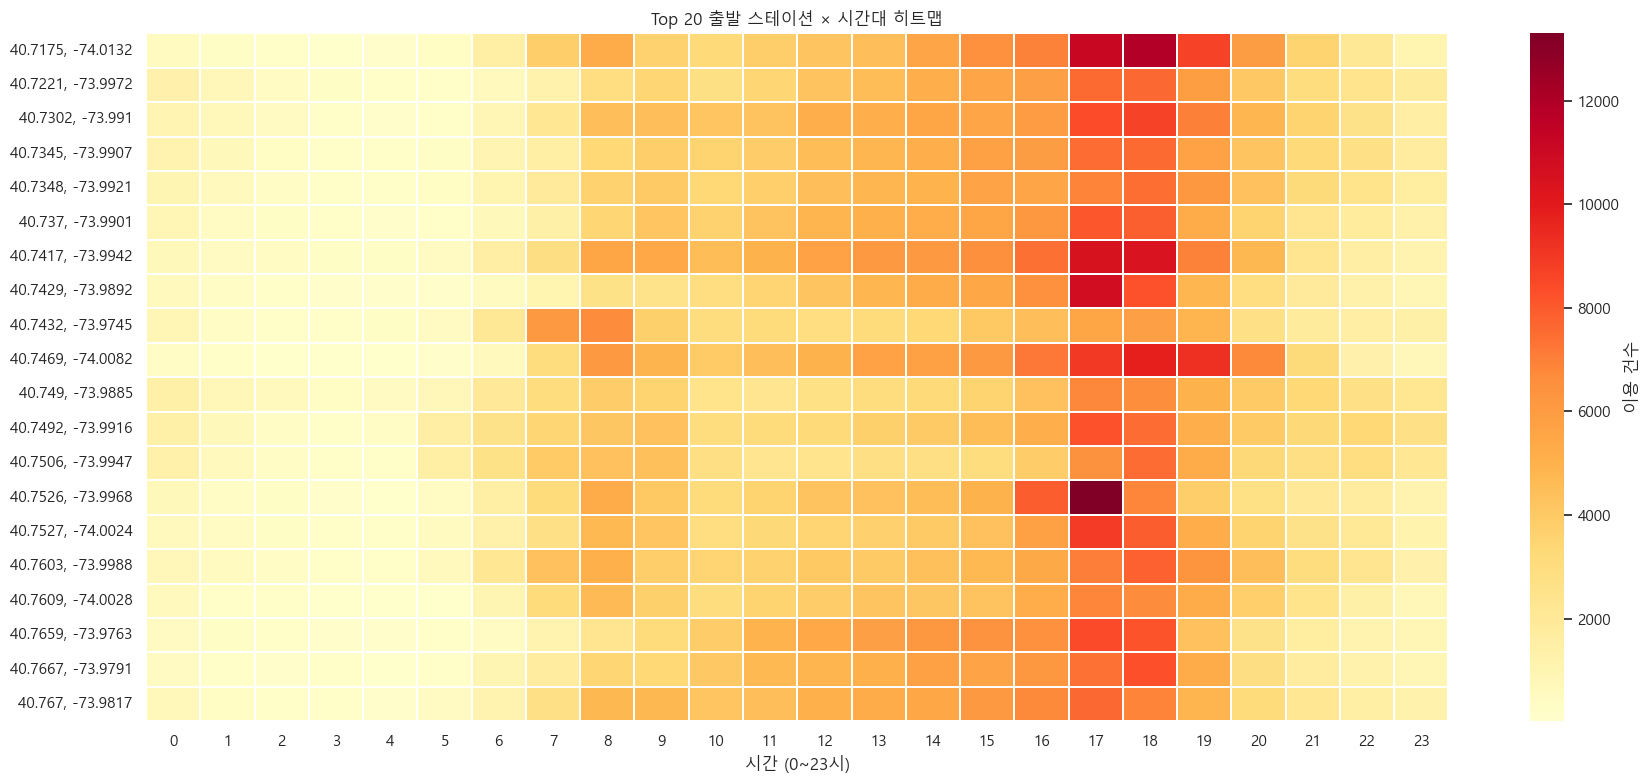

In [30]:
# Top 20 스테이션 × 시간대

df['station_id'] = df['start_lat'].round(4).astype(str) + ", " + df['start_lng'].round(4).astype(str)

start_cnt = df.groupby('station_id').size().sort_values(ascending=False)
top20 = start_cnt.head(20).index.tolist()

heatmap_data = (
    df[df['station_id'].isin(top20)]
    .assign(hour=df['started_at'].dt.hour)
    .groupby(['station_id', 'hour'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3,
            ax=ax, cbar_kws={'label': '이용 건수'})
ax.set_title('Top 20 출발 스테이션 × 시간대 히트맵')
ax.set_xlabel('시간 (0~23시)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

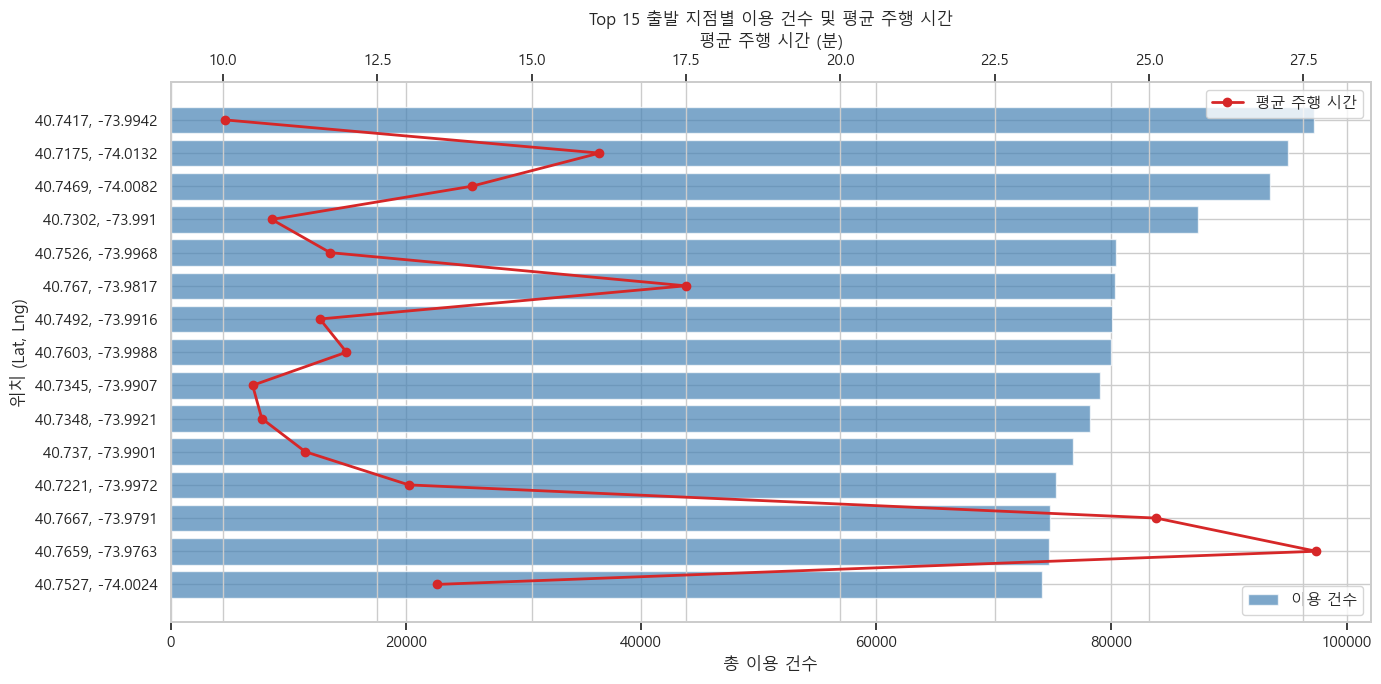

In [34]:
station_stats = (
    df.groupby('station_id')
      .agg(avg_duration=('duration_min', 'mean'),
           count=('duration_min', 'size'))
      .sort_values('count', ascending=False)
      .head(15)
)

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.barh(station_stats.index, station_stats['count'], color='steelblue', alpha=0.7, label='이용 건수')
ax1.set_xlabel('총 이용 건수')
ax1.set_ylabel('위치 (Lat, Lng)')
ax1.invert_yaxis()

ax2 = ax1.twiny()
ax2.plot(station_stats['avg_duration'], station_stats.index, color='tab:red', marker='o', linewidth=2, label='평균 주행 시간')
ax2.set_xlabel('평균 주행 시간 (분)')

plt.title('Top 15 출발 지점별 이용 건수 및 평균 주행 시간')
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

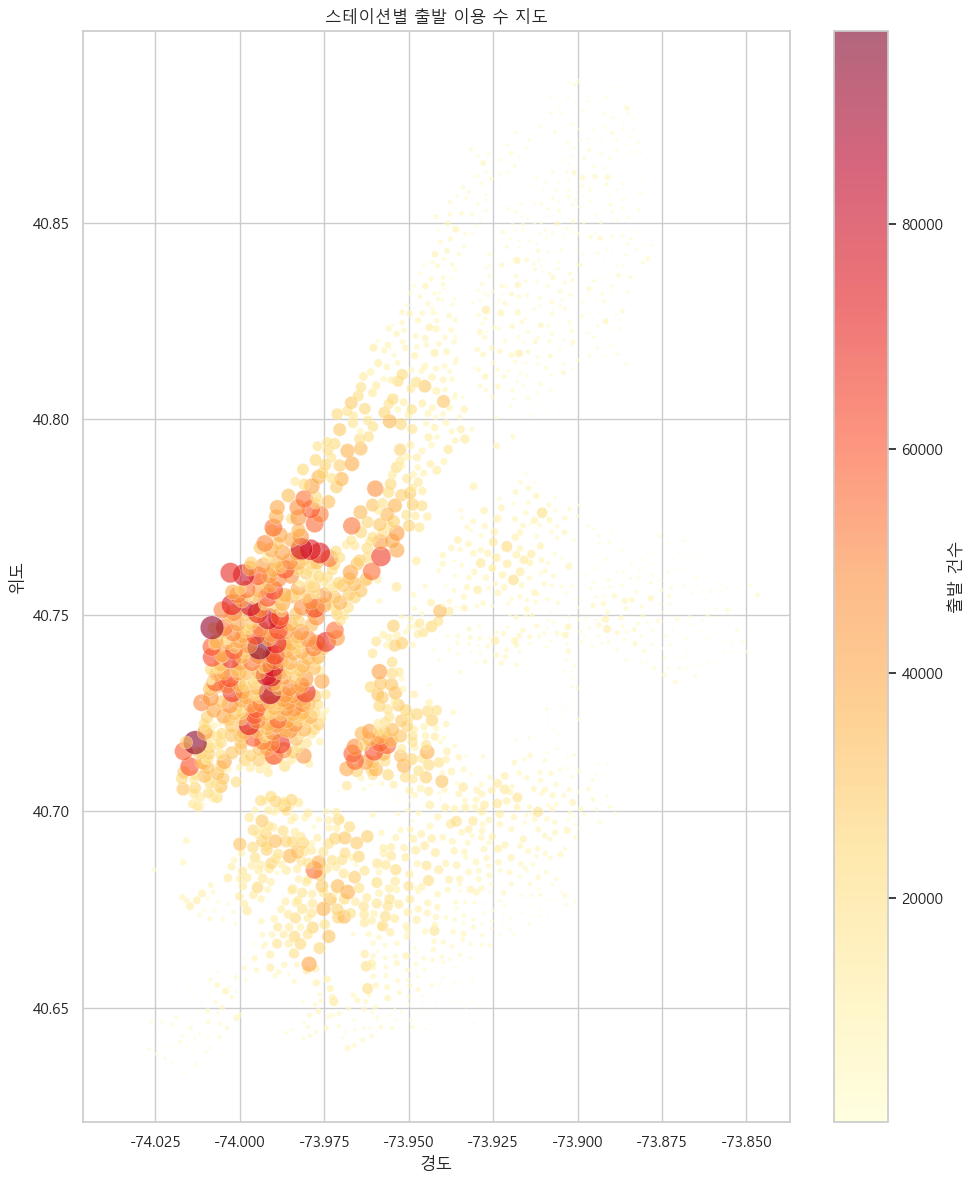

In [37]:
# 스테이션 위치
station_geo = (
    df.groupby('station_id')
      .agg(lat=('start_lat', 'mean'),
           lng=('start_lng', 'mean'),
           count=('start_lat', 'size'))
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 12))
sc = ax.scatter(
    station_geo['lng'], station_geo['lat'],
    s=station_geo['count'] / station_geo['count'].max() * 300,
    c=station_geo['count'], cmap='YlOrRd',
    alpha=0.6, edgecolors='white', linewidths=0.3
)

plt.colorbar(sc, ax=ax, label='출발 건수')
ax.set_title('스테이션별 출발 이용 수 지도')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
plt.tight_layout()
plt.show()